# Анализ Russian Financial Statements Database

Цель работы — провести разведочный анализ выборки данных RFSD, включающей 1 000 наблюдений и 20 признаков.

В работе выполняются:

- описательная статистика;
- анализ распределений;
- поиск выбросов и аномалий;
- корреляционный анализ;
- визуализация взаимосвязей;
- формулирование выводов.

In [2]:
!pip install polars pyarrow seaborn matplotlib

In [3]:
%pip install datasets

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from datasets import load_dataset
from itertools import combinations

In [5]:
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

In [6]:
#создаем соединение с базой
stream_data = load_dataset(
    "irlspbru/RFSD",
    data_files="RFSD/year=2023/part-0.parquet",
    split="train",
    streaming=True,
)

README.md:   0%|          | 0.00/19.0k [00:00<?, ?B/s]

In [7]:
#проверяем дсотупность датасета
column_names = stream_data.column_names

print(f"Количество колонок: {len(column_names)}")
print(column_names[:30])

Количество колонок: 213
['inn', 'ogrn', 'region', 'region_taxcode', 'creation_date', 'dissolution_date', 'age', 'eligible', 'exemption_criteria', 'financial', 'filed', 'imputed', 'simplified', 'articulated', 'totals_adjustment', 'outlier', 'okved', 'okved_section', 'okpo', 'okopf', 'okogu', 'okfc', 'oktmo', 'lon', 'lat', 'geocoding_quality', 'line_1100', 'line_1110', 'line_1120', 'line_1130']


In [8]:
# загружаем справочник, чтобы были понятные названия для колонок
NAMES_URL = (
    "https://raw.githubusercontent.com/"
    "irlcode/RFSD/main/"
    "aux_data/descriptive_names_dict.csv"
)

names_dictionary = pd.read_csv(NAMES_URL)

names_dictionary.head(20)

,original,descriptive
0,year,year
1,inn,inn
2,ogrn,ogrn
3,region,region
4,region_taxcode,region_taxcode
5,creation_date,creation_date
6,dissolution_date,dissolution_date
7,age,age
8,eligible,eligible
9,exemption_criteria,exemption_criteria


In [9]:
# проверяю, что названия подтянулись
print(f"Размер справочника: {names_dictionary.shape}")

different_names = names_dictionary[
    names_dictionary["original"]
    != names_dictionary["descriptive"]
]

different_names.head(20)

Размер справочника: (211, 2)


,original,descriptive
24,line_1100,B_noncurrent_assets
25,line_1110,B_intangible_assets
26,line_1120,B_research_development
27,line_1130,B_intangible_exploration
28,line_1140,B_tangible_exploration
29,line_1150,B_fixed_assets
30,line_1160,B_tangible_invest
31,line_1170,B_fin_invest
32,line_1180,B_def_tax_assets
33,line_1190,B_other_noncurrent_assets


In [10]:
selected_columns = [
    "line_1100",  # внеоборотные активы
    "line_1150",  # основные средства
    "line_1200",  # оборотные активы
    "line_1210",  # запасы
    "line_1230",  # дебиторская задолженность
    "line_1250",  # денежные средства
    "line_1300",  # капитал и резервы
    "line_1400",  # долгосрочные обязательства
    "line_1410",  # долгосрочные заёмные средства
    "line_1500",  # краткосрочные обязательства
    "line_1510",  # краткосрочные заёмные средства
    "line_1520",  # кредиторская задолженность
    "line_1600",  # активы — итого
    "line_1700",  # пассивы — итого
    "line_2100",  # валовая прибыль
    "line_2110",  # выручка
    "line_2120",  # себестоимость продаж
    "line_2200",  # прибыль от продаж
    "line_2300",  # прибыль до налогообложения
    "line_2400",  # чистая прибыль
]

missing_columns = [
    column
    for column in selected_columns
    if column not in column_names
]

print(f"Выбрано колонок: {len(selected_columns)}")
print(f"Не найденные колонки: {missing_columns}")

Выбрано колонок: 20
Не найденные колонки: []


In [11]:
selected_stream = stream_data.select_columns(
    selected_columns
)

print(selected_stream.column_names)
print(
    f"Количество колонок после отбора: "
    f"{len(selected_stream.column_names)}"
)

['line_1100', 'line_1150', 'line_1200', 'line_1210', 'line_1230', 'line_1250', 'line_1300', 'line_1400', 'line_1410', 'line_1500', 'line_1510', 'line_1520', 'line_1600', 'line_1700', 'line_2100', 'line_2110', 'line_2120', 'line_2200', 'line_2300', 'line_2400']
Количество колонок после отбора: 20


In [12]:
# Данные внутри года не перемешаны.
# Используем воспроизводимое буферное перемешивание

shuffled_stream = selected_stream.shuffle(
    seed=42,
    buffer_size=10_000,
)

In [13]:
sample_records = list(
    shuffled_stream.take(1_000)
)

df = pd.DataFrame(sample_records)

print(f"Размер датасета: {df.shape}")

Размер датасета: (1000, 20)


In [14]:
rename_mapping = dict(
    zip(
        names_dictionary["original"],
        names_dictionary["descriptive"],
    )
)

df = df.rename(columns=rename_mapping)

print(df.columns.tolist())

['B_noncurrent_assets', 'B_fixed_assets', 'B_current_assets', 'B_inventories', 'B_accounts_receivable', 'B_cash_equivalents', 'B_total_equity', 'B_longterm_liab', 'B_longterm_debt', 'B_shortterm_liab', 'B_shortterm_debt', 'B_shortterm_payables', 'B_assets', 'B_liab', 'PL_gross_profit', 'PL_revenue', 'PL_cost_of_sales', 'PL_profit_from_sales', 'PL_before_tax', 'PL_net_profit']


In [15]:
#основная инфа и типы данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   B_noncurrent_assets    380 non-null    float64
 1   B_fixed_assets         329 non-null    float64
 2   B_current_assets       641 non-null    float64
 3   B_inventories          438 non-null    float64
 4   B_accounts_receivable  485 non-null    float64
 5   B_cash_equivalents     553 non-null    float64
 6   B_total_equity         677 non-null    float64
 7   B_longterm_liab        238 non-null    float64
 8   B_longterm_debt        207 non-null    float64
 9   B_shortterm_liab       519 non-null    float64
 10  B_shortterm_debt       202 non-null    float64
 11  B_shortterm_payables   499 non-null    float64
 12  B_assets               730 non-null    float64
 13  B_liab                 730 non-null    float64
 14  PL_gross_profit        307 non-null    float64
 15  PL_re

In [16]:
#описательная статистика
descriptive_stats = df.describe().T

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
B_noncurrent_assets,380.00,"43,979.78","288,441.33",0.00,10.00,719.50,"5,449.75","3,787,667.00"
B_fixed_assets,329.00,"31,551.66","146,200.63",0.00,47.00,"1,150.00","6,194.00","1,785,338.00"
B_current_assets,641.00,"32,521.11","216,347.87",-10.00,50.00,837.00,"7,627.00","4,705,272.00"
B_inventories,438.00,"13,717.45","71,430.26",0.00,10.00,396.00,"3,733.50","1,136,280.00"
B_accounts_receivable,485.00,"23,837.41","172,451.00",0.00,29.00,509.00,"4,525.00","3,489,649.00"
B_cash_equivalents,553.00,"4,029.78","41,410.25",-10.00,9.00,84.00,598.00,"882,131.00"
B_total_equity,677.00,"9,246.94","306,257.56","-6,265,767.00",0.00,137.00,"3,019.00","4,521,411.00"
B_longterm_liab,238.00,"62,136.32","557,511.59","-11,724.00",0.00,472.50,"6,520.50","8,461,700.00"
B_longterm_debt,207.00,"64,385.69","580,547.80","-11,874.00",0.00,461.00,"5,681.00","8,262,090.00"
B_shortterm_liab,519.00,"31,762.27","259,329.58","-4,284.00",54.00,801.00,"5,648.00","4,855,710.00"


### Выводы по описательной статистике

В финансовых показателях много пропусков. Например, общая сумма активов заполнена для 730 компаний, выручка — для 488, а чистая прибыль — для 552 компаний из 1 000. Поэтому расчёты по разным колонкам основаны на разном количестве наблюдений.

Средние значения заметно выше медианных. Например, средняя выручка составляет около 71,7 тыс., а медианная — около 4,2 тыс. Это означает, что несколько компаний с очень крупными показателями сильно увеличивают среднее значение.

По чистой прибыли встречаются как положительные, так и отрицательные значения. Отрицательные значения означают, что компания получила убыток.

In [17]:
histogram_columns = [
    rename_mapping["line_1600"],
    rename_mapping["line_2110"],
    rename_mapping["line_2400"],
]

print(histogram_columns)

['B_assets', 'PL_revenue', 'PL_net_profit']


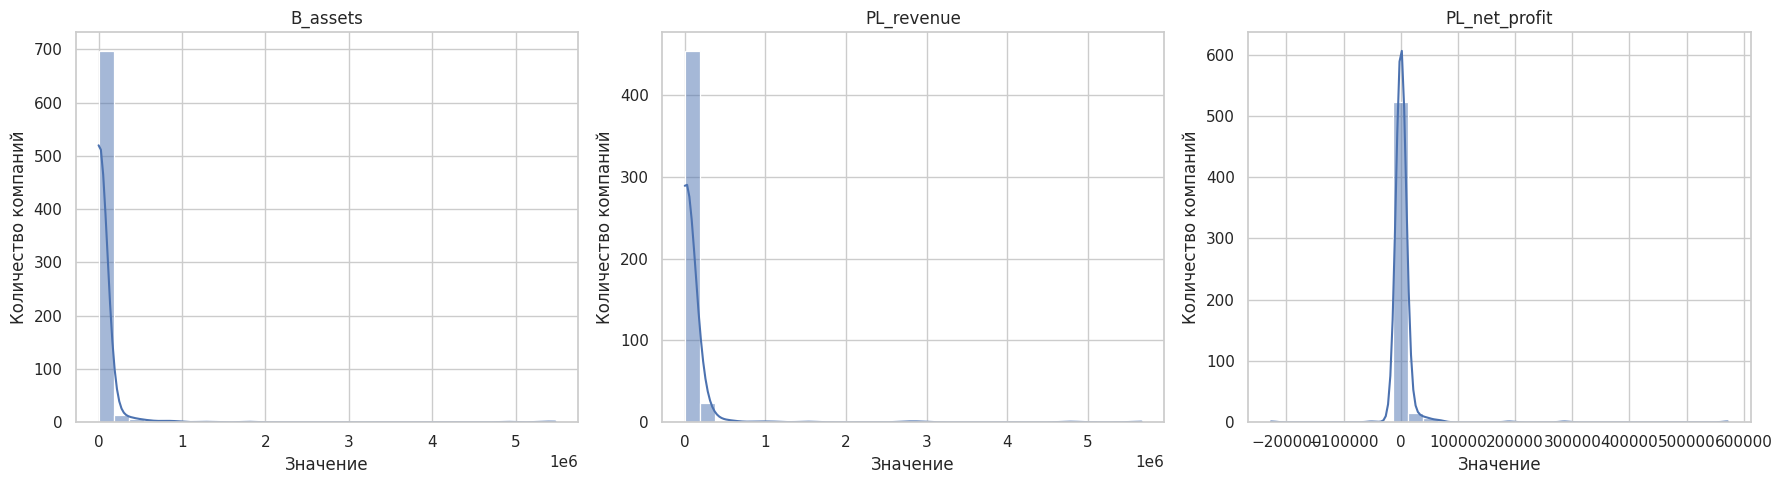

In [18]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5),
)

for axis, column in zip(
    axes,
    histogram_columns,
):
    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True,
        ax=axis,
    )

    axis.set_title(column)
    axis.set_xlabel("Значение")
    axis.set_ylabel("Количество компаний")

plt.tight_layout()
plt.show()

Выводы по графикам:

На всех трёх графиках большая часть наблюдений сосредоточена около нулевой отметки. Однако это не обязательно означает, что показатели компаний действительно равны нулю. Из-за нескольких очень больших значений шкала графиков сильно растянулась, поэтому обычные значения визуально сжались в узкой области.

Наиболее заметно это для активов и выручки: у основной части компаний показатели существенно ниже максимальных значений в выборке. Это может объясняться тем, что в выборку одновременно попали компании разного масштаба — от небольших организаций до отдельных крупных компаний.

По чистой прибыли также наблюдается концентрация значений около нуля, но распределение включает как положительные, так и отрицательные значения.

На графиках присутствуют потенциальные выбросы — отдельные значения, значительно удалённые от основной массы. Однако по одной гистограмме нельзя определить, являются ли они ошибками в данных или реальными показателями крупных компаний.

В текущем масштабе графики плохо показывают распределение основной части наблюдений. Для более точного вывода необходимо отдельно проверить количество фактических нулей, квартильные значения и долю выбросов.

In [19]:
distribution_check = pd.DataFrame(
    {
        "Непустые значения": df[histogram_columns].count(),
        "Пропуски": df[histogram_columns].isna().sum(),
        "Количество нулей": df[histogram_columns].eq(0).sum(),
        "Доля нулей, %": (
            df[histogram_columns].eq(0).sum()
            / df[histogram_columns].count()
            * 100
        ),
        "Отрицательные значения": (
            df[histogram_columns].lt(0).sum()
        ),
        "Медиана": df[histogram_columns].median(),
        "25%": df[histogram_columns].quantile(0.25),
        "75%": df[histogram_columns].quantile(0.75),
        "Максимум": df[histogram_columns].max(),
    }
).round(2)

distribution_check

,Непустые значения,Пропуски,Количество нулей,"Доля нулей, %",Отрицательные значения,Медиана,25%,75%,Максимум
B_assets,730,270,112,15.34,1,777.00,11.25,"8,958.75","5,475,369.00"
PL_revenue,488,512,49,10.04,0,"4,215.50",554.50,"27,604.50","5,668,642.00"
PL_net_profit,552,448,90,16.30,129,34.00,0.00,691.00,"571,905.00"


In [20]:
#матрица корреляции

correlation_matrix = df.corr(
    method="pearson"
)

print(
    f"Размер матрицы корреляции: "
    f"{correlation_matrix.shape}"
)

correlation_matrix

Размер матрицы корреляции: (20, 20)


,B_noncurrent_assets,B_fixed_assets,B_current_assets,B_inventories,B_accounts_receivable,B_cash_equivalents,B_total_equity,B_longterm_liab,B_longterm_debt,B_shortterm_liab,B_shortterm_debt,B_shortterm_payables,B_assets,B_liab,PL_gross_profit,PL_revenue,PL_cost_of_sales,PL_profit_from_sales,PL_before_tax,PL_net_profit
B_noncurrent_assets,1.00,0.85,0.48,0.34,0.37,0.68,-0.07,0.67,0.90,0.51,0.19,0.59,0.87,0.87,0.82,0.49,-0.41,0.66,0.71,0.69
B_fixed_assets,0.85,1.00,0.54,0.42,0.41,0.69,-0.27,0.73,0.74,0.61,0.44,0.68,0.81,0.81,0.55,0.50,-0.45,0.33,0.37,0.36
B_current_assets,0.48,0.54,1.00,0.87,0.96,0.38,-0.02,0.32,0.33,0.94,0.92,0.89,0.86,0.86,0.52,0.87,-0.86,0.39,0.38,0.38
B_inventories,0.34,0.42,0.87,1.00,0.78,0.20,0.01,0.23,0.23,0.77,0.79,0.71,0.70,0.70,0.37,0.77,-0.67,0.30,0.20,0.21
B_accounts_receivable,0.37,0.41,0.96,0.78,1.00,0.20,0.12,0.13,0.14,0.88,0.93,0.80,0.77,0.77,0.46,0.85,-0.85,0.37,0.34,0.34
B_cash_equivalents,0.68,0.69,0.38,0.20,0.20,1.00,-0.62,0.89,0.97,0.54,0.08,0.67,0.62,0.62,0.48,0.38,-0.35,0.29,0.46,0.45
B_total_equity,-0.07,-0.27,-0.02,0.01,0.12,-0.62,1.00,-0.78,-0.96,-0.31,0.11,-0.42,-0.05,-0.05,0.27,0.18,-0.16,0.34,0.31,0.30
B_longterm_liab,0.67,0.73,0.32,0.23,0.13,0.89,-0.78,1.00,1.00,0.53,0.10,0.66,0.58,0.58,0.30,0.18,-0.15,0.13,0.22,0.21
B_longterm_debt,0.90,0.74,0.33,0.23,0.14,0.97,-0.96,1.00,1.00,0.53,0.07,0.67,0.68,0.68,0.63,0.24,-0.20,0.27,0.52,0.49
B_shortterm_liab,0.51,0.61,0.94,0.77,0.88,0.54,-0.31,0.53,0.53,1.00,0.98,0.98,0.84,0.84,0.45,0.74,-0.74,0.33,0.29,0.29


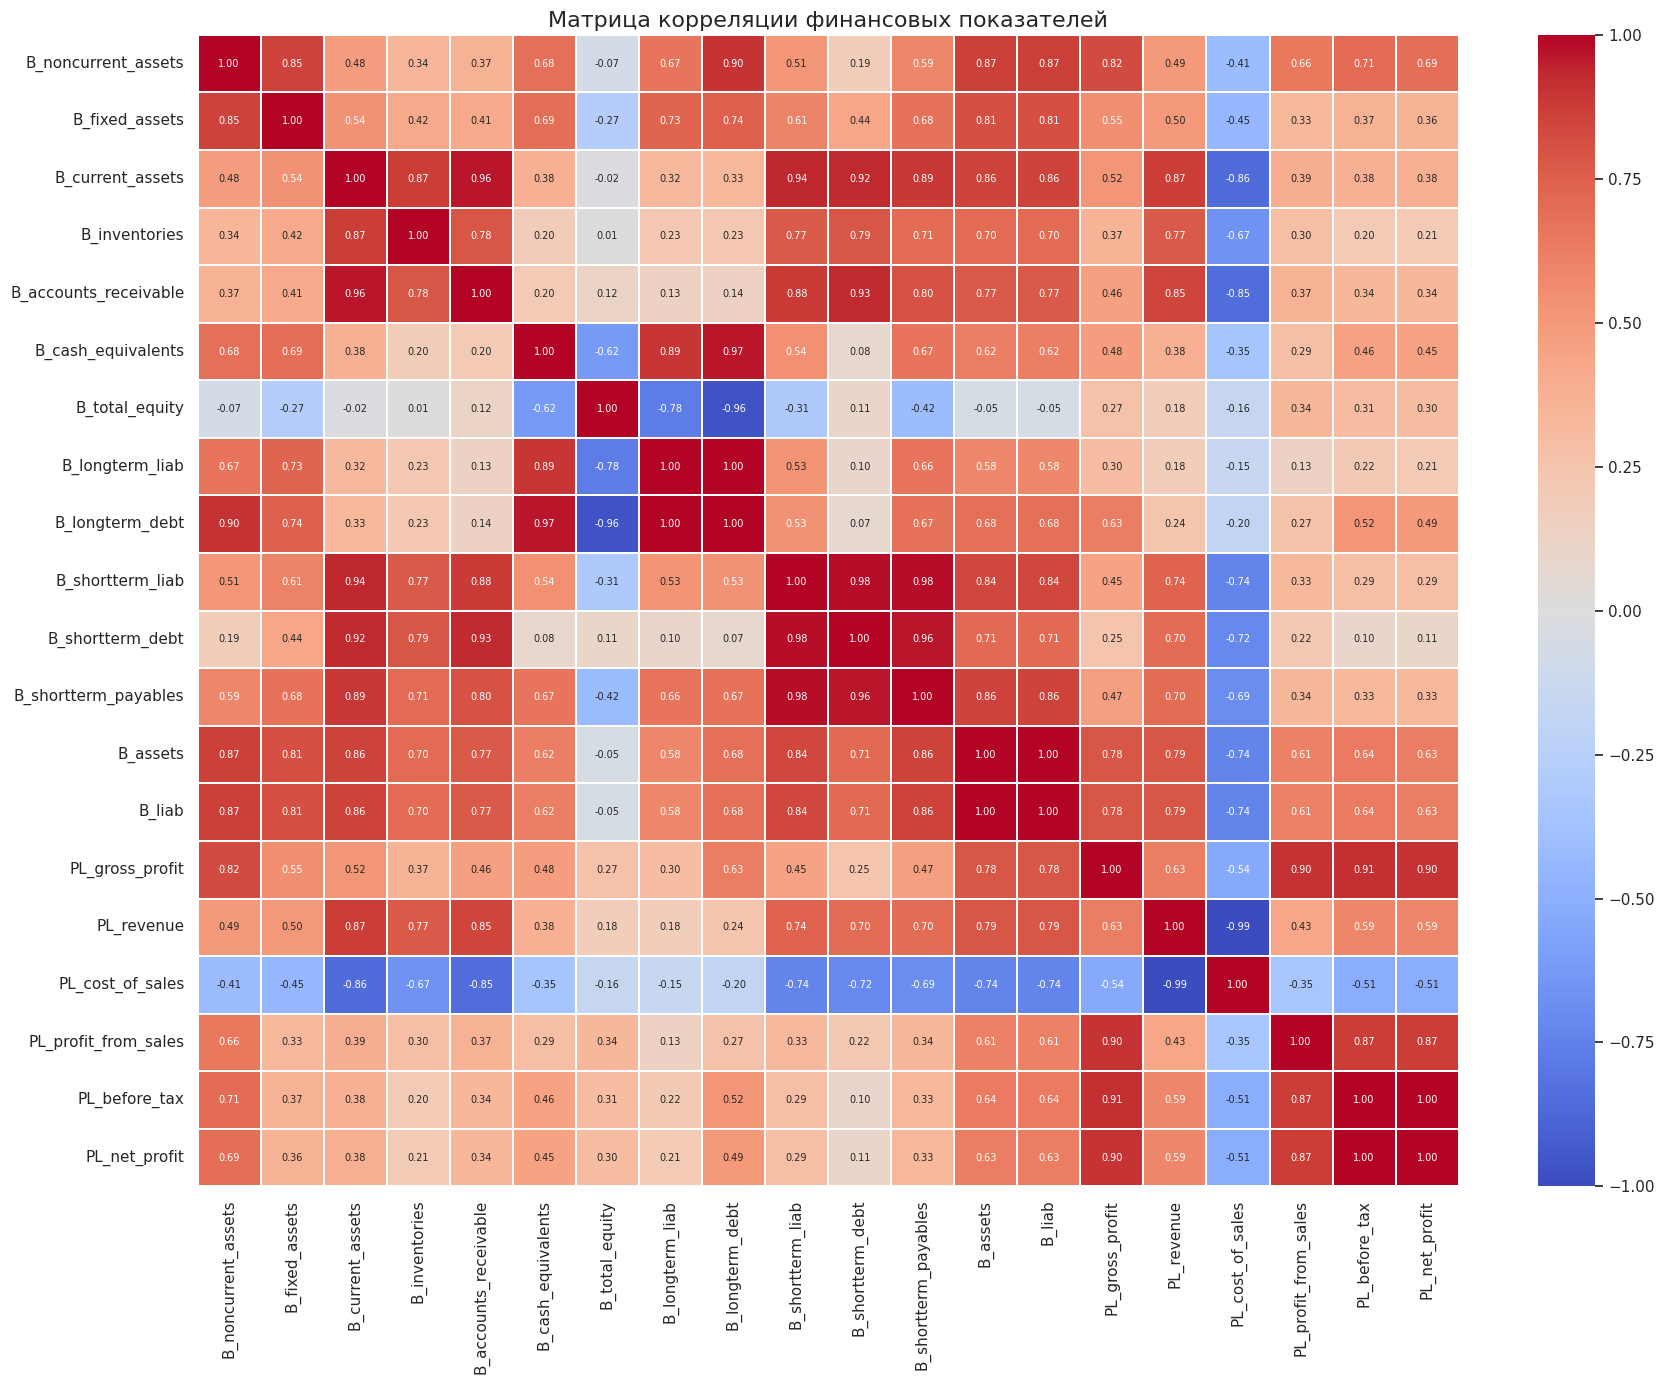

In [21]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot_kws={"size": 7},
)

plt.title(
    "Матрица корреляции финансовых показателей",
    fontsize=16,
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Выводы по матрице корреляции

В матрице видно несколько сильных связей:

1. **Активы и пассивы имеют корреляцию `1,00`.**  
   Это ожидаемо, поскольку в бухгалтерском балансе сумма активов должна быть равна сумме пассивов.

2. **Выручка и себестоимость имеют корреляцию `−0,99`.**  
   Чем больше компания продаёт, тем больше у неё расходов на эти продажи. Корреляция отрицательная, потому что себестоимость записана со знаком минус.

3. **Прибыль до налогообложения и чистая прибыль имеют корреляцию `1,00`.**  
   Эти показатели тесно связаны: чистая прибыль рассчитывается на основе прибыли до налогообложения с учётом налогов и других корректировок.

4. **Оборотные активы и дебиторская задолженность имеют корреляцию `0,96`.**  
   Дебиторская задолженность входит в состав оборотных активов, поэтому при росте одного показателя обычно растёт и другой.

Часть сильных связей объясняется не случайными закономерностями, а тем, как устроена финансовая отчётность. Одни показатели входят в состав других или используются при их расчёте.

In [22]:
strong_correlations = []

for first_column, second_column in combinations(
    df.columns,
    2,
):
    pair_data = df[
        [first_column, second_column]
    ].dropna()

    correlation = pair_data[
        first_column
    ].corr(
        pair_data[second_column]
    )

    if abs(correlation) >= 0.90:
        strong_correlations.append(
            {
                "Колонка 1": first_column,
                "Колонка 2": second_column,
                "Корреляция": correlation,
                "Количество наблюдений": len(pair_data),
            }
        )

strong_correlations_df = (
    pd.DataFrame(strong_correlations)
    .sort_values(
        by="Корреляция",
        key=abs,
        ascending=False,
    )
    .reset_index(drop=True)
)

strong_correlations_df

,Колонка 1,Колонка 2,Корреляция,Количество наблюдений
0,B_assets,B_liab,1.00,730
1,PL_before_tax,PL_net_profit,1.00,536
2,B_longterm_liab,B_longterm_debt,1.00,207
3,PL_revenue,PL_cost_of_sales,-0.99,453
4,B_shortterm_liab,B_shortterm_payables,0.98,499
5,B_shortterm_liab,B_shortterm_debt,0.98,202
6,B_cash_equivalents,B_longterm_debt,0.97,201
7,B_current_assets,B_accounts_receivable,0.96,485
8,B_total_equity,B_longterm_debt,-0.96,201
9,B_shortterm_debt,B_shortterm_payables,0.96,189


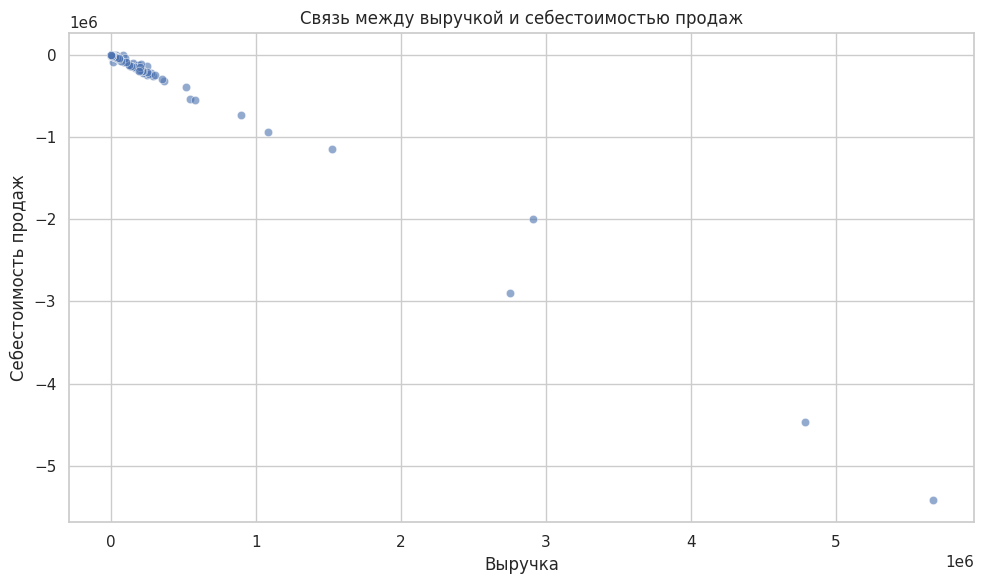

In [23]:
scatter_data = df[
    ["PL_revenue", "PL_cost_of_sales"]
].dropna()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=scatter_data,
    x="PL_revenue",
    y="PL_cost_of_sales",
    alpha=0.6,
)

plt.title(
    "Связь между выручкой и себестоимостью продаж"
)
plt.xlabel("Выручка")
plt.ylabel("Себестоимость продаж")

plt.tight_layout()
plt.show()

### Вывод по диаграмме рассеивания

График показывает понятную связь: чем больше выручка компании, тем выше её себестоимость. Себестоимость отражается отрицательным значением, поэтому точки идут вниз, а корреляция получилась отрицательной — `−0,99`.

Большинство точек находится около начала координат. Это связано не с тем, что показатели равны нулю, а с тем, что в выборке есть несколько компаний с очень крупными значениями. Из-за них масштаб графика растягивается, и остальные компании визуально располагаются очень близко друг к другу.

В целом связь выглядит логичной: чем больше компания продаёт, тем больше у неё расходов, связанных с продажами. При этом на итоговую корреляцию могут заметно влиять несколько самых крупных компаний.

In [24]:
outlier_results = []

for column in histogram_columns:
    values = df[column].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = values[
        (values < lower_bound)
        | (values > upper_bound)
    ]

    outlier_results.append(
        {
            "Показатель": column,
            "Нижняя граница": lower_bound,
            "Верхняя граница": upper_bound,
            "Количество выбросов": len(outliers),
            "Доля выбросов, %": (
                len(outliers) / len(values) * 100
            ),
        }
    )

outlier_summary = pd.DataFrame(
    outlier_results
).round(2)

outlier_summary

,Показатель,Нижняя граница,Верхняя граница,Количество выбросов,"Доля выбросов, %"
0,B_assets,"-13,410.00","22,380.00",118,16.16
1,PL_revenue,"-40,020.50","68,179.50",64,13.11
2,PL_net_profit,"-1,036.50","1,727.50",137,24.82


### Вывод по выбросам

Метод IQR подтвердил, что во всех трёх показателях есть значения, которые сильно отличаются от основной части выборки.

- Для активов выбросами признаны 118 значений, или около 16% наблюдений.
- Для выручки — 64 значения, или около 13%.
- Для чистой прибыли — 137 значений, или около 25%.

Особенно много выбросов получилось по чистой прибыли. Это связано с тем, что у большинства компаний прибыль находится в относительно узком диапазоне около нуля, но при этом встречаются как крупные прибыли, так и крупные убытки.

Высокая доля выбросов не означает, что все эти значения ошибочны. Скорее всего, метод IQR относит к выбросам показатели крупных компаний, которые заметно отличаются от основной части выборки. Поэтому найденные значения можно считать статистическими выбросами, но не подтверждёнными ошибками в данных.

In [25]:
anomaly_check = pd.DataFrame(
    {
        "Показатель": [
            "B_assets",
            "PL_revenue",
        ],
        "Отрицательных значений": [
            (df["B_assets"] < 0).sum(),
            (df["PL_revenue"] < 0).sum(),
        ],
        "Нулевых значений": [
            (df["B_assets"] == 0).sum(),
            (df["PL_revenue"] == 0).sum(),
        ],
        "Минимальное значение": [
            df["B_assets"].min(),
            df["PL_revenue"].min(),
        ],
    }
)

anomaly_check

,Показатель,Отрицательных значений,Нулевых значений,Минимальное значение
0,B_assets,1,112,-10.00
1,PL_revenue,0,49,0.00


### Проверка возможных аномалий

В выручке отрицательных значений нет, поэтому явных некорректных значений по этому признаку не обнаружено. При этом у 49 компаний выручка равна нулю. Это может быть связано с отсутствием деятельности или с тем, что компания не предоставила полноценную отчётность.

По активам найдено одно отрицательное значение `−10`. Общая сумма активов обычно не должна быть отрицательной, поэтому это значение можно считать потенциальной аномалией. Без дополнительной информации нельзя точно определить, связано ли оно с ошибкой в исходной отчётности, особенностями обработки данных или корректировкой показателя.

Также у 112 компаний активы равны нулю. Это довольно много, но само по себе не доказывает ошибку: RFSD включает в том числе компании, которые не подавали финансовую отчётность или имели пустые показатели.

## Итоговые выводы

По результатам анализа можно выделить несколько основных наблюдений:

1. **Компании в выборке сильно отличаются по масштабу.**  
   Большинство значений активов, выручки и прибыли находится в нижней части диапазона, но есть несколько компаний с показателями в разы выше остальных. Из-за этого распределения получились сильно смещёнными, а доля статистических выбросов составила от 13% до 25%.

2. **Выручка тесно связана с себестоимостью продаж.**  
   Корреляция между ними составила `−0,99`. Отрицательный знак объясняется тем, что себестоимость записана со знаком минус. В целом связь логична: чем больше компания продаёт, тем больше у неё расходов на продажи.

3. **Часть сильных корреляций объясняется устройством бухгалтерской отчётности.**  
   Например, активы и пассивы имеют корреляцию `1,00`, поскольку их итоговые суммы в бухгалтерском балансе должны быть равны. Прибыль до налогообложения и чистая прибыль также почти полностью повторяют друг друга, поскольку один показатель рассчитывается на основе другого.

4. **В данных найдена потенциальная аномалия.**  
   У одной компании общая сумма активов равна `−10`, хотя активы обычно не могут быть отрицательными. Это значение требует отдельной проверки по исходной отчётности.

5. **Нулевые и пропущенные значения необходимо интерпретировать осторожно.**  
   RFSD включает в том числе компании, которые могли не подать финансовую отчётность. Возможно по компаниям просто не отражены результаты

Результаты относятся только к выборке из 1 000 компаний за 2023 год. Кроме того, на рассчитанные корреляции могут заметно влиять несколько наиболее крупных компаний.

Хотелось проверить, почему есть нулевая выручка. По итогам, это не связано с подачей отчетности. Вероятно другие причины - отсутствие продаж, временная приостановка деятельности или компания ещё не начала получать выручку. Точно определить причину по выбранным данным нельзя.

In [26]:
diagnostic_columns = [
    "inn",
    "filed",
    "imputed",
    "simplified",
    "outlier",
    "line_2110",
    "line_1600",
]

diagnostic_stream = (
    stream_data
    .select_columns(diagnostic_columns)
    .shuffle(
        seed=42,
        buffer_size=10_000,
    )
)

diagnostic_records = list(
    diagnostic_stream.take(1_000)
)

diagnostic_df = pd.DataFrame(
    diagnostic_records
)

print(
    "Нулевая выручка:",
    (diagnostic_df["line_2110"] == 0).sum(),
)

print(
    "Нулевые активы:",
    (diagnostic_df["line_1600"] == 0).sum(),
)

Нулевая выручка: 49
Нулевые активы: 112


In [27]:
zero_revenue_data = diagnostic_df[
    diagnostic_df["line_2110"] == 0
].copy()

zero_revenue_summary = (
    zero_revenue_data[
        [
            "filed",
            "imputed",
            "simplified",
            "outlier",
        ]
    ]
    .value_counts(dropna=False)
    .reset_index(name="Количество компаний")
)

zero_revenue_summary

,filed,imputed,simplified,outlier,Количество компаний
0,1.00,0.00,0.00,0.00,24
1,1.00,0.00,1.00,0.00,24
2,0.00,1.00,1.00,0.00,1
